---
title: "Site location problems without geometry and mapping"
image: image.png
toc: true
execute: 
  enabled: true
---

Lokigi can also support answering site location problems with a very minimal dataset - just the travel matrix, in fact! 

However, here we're also going to pass in a demand matrix as we know how much demand is coming from each location. However, the site names we've been given and the postcode sector names have been anonymised, so we are unable to map them back to an actual geographical region that we can plot. 

In [1]:
from lokigi.site import SiteProblem

First, let's initialise our `SiteProblem()` and add the demand and travel data. 

:::{.callout-note}
The data for this problem comes from [github.com/health-data-science-OR/healthcare-logistics](https://github.com/health-data-science-OR/healthcare-logistics) and is reused under the MIT licence. 

Credit for the creation of this dataset goes to [Dr Tom Monks](https://github.com/TomMonks). 
:::

:::{.callout-note collapse="true"}
### Click here to view the licence for this dataset

```{md}
MIT License

Copyright (c) 2020 health-data-science-OR

Permission is hereby granted, free of charge, to any person obtaining a copy
of this software and associated documentation files (the "Software"), to deal
in the Software without restriction, including without limitation the rights
to use, copy, modify, merge, publish, distribute, sublicense, and/or sell
copies of the Software, and to permit persons to whom the Software is
furnished to do so, subject to the following conditions:

The above copyright notice and this permission notice shall be included in all
copies or substantial portions of the Software.

THE SOFTWARE IS PROVIDED "AS IS", WITHOUT WARRANTY OF ANY KIND, EXPRESS OR
IMPLIED, INCLUDING BUT NOT LIMITED TO THE WARRANTIES OF MERCHANTABILITY,
FITNESS FOR A PARTICULAR PURPOSE AND NONINFRINGEMENT. IN NO EVENT SHALL THE
AUTHORS OR COPYRIGHT HOLDERS BE LIABLE FOR ANY CLAIM, DAMAGES OR OTHER
LIABILITY, WHETHER IN AN ACTION OF CONTRACT, TORT OR OTHERWISE, ARISING FROM,
OUT OF OR IN CONNECTION WITH THE SOFTWARE OR THE USE OR OTHER DEALINGS IN THE
SOFTWARE.
```

:::


In [2]:
problem = SiteProblem()

problem.add_demand("https://github.com/health-data-science-OR/healthcare-logistics/blob/master/optimisation/data/sh_demand.csv", demand_col="n_patients", location_id_col="sector")

In [3]:
problem.show_demand()

,sector,n_patients
0,PS1,3375
1,PS2,3338
2,PS3,2922
3,PS4,3191
4,PS5,3134
...,...,...
273,PS274,216
274,PS275,261
275,PS276,342
276,PS277,0


In [4]:
problem.add_travel_matrix(
    "https://github.com/health-data-science-OR/healthcare-logistics/blob/master/optimisation/data/clinic_car_travel_time.csv",
    source_col="sector"
    )

In [5]:
problem.show_travel_matrix()

,sector,clinic_1,clinic_2,clinic_3,clinic_4,clinic_5,clinic_6,clinic_7,clinic_8,clinic_9,...,clinic_19,clinic_20,clinic_21,clinic_22,clinic_23,clinic_24,clinic_25,clinic_26,clinic_27,clinic_28
0,PS158,33.17,40.15,38.17,37.93,29.35,51.48,53.28,48.00,53.82,...,12.10,12.27,15.83,53.27,53.98,29.75,34.22,32.68,19.62,39.25
1,PS159,31.42,36.55,36.42,34.53,27.60,47.88,49.68,44.40,50.22,...,11.75,11.92,10.62,49.68,50.38,26.15,30.62,32.35,19.28,35.65
2,PS160,31.82,38.80,36.82,36.58,28.00,50.13,51.95,46.65,52.47,...,10.75,10.92,14.35,51.93,52.65,28.40,32.87,31.35,18.27,37.90
3,PS161,31.68,38.65,36.67,36.43,27.87,49.98,51.80,46.50,52.32,...,10.32,10.77,16.38,51.78,52.50,28.27,32.73,31.20,17.82,37.75
4,PS162,29.55,36.53,34.55,34.32,25.73,47.87,49.67,44.38,50.20,...,6.77,7.28,17.18,49.65,50.37,26.13,30.60,29.07,14.27,35.63
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
273,PS273,34.13,21.83,39.23,35.90,34.70,49.25,49.08,45.78,51.58,...,54.62,53.95,43.67,51.05,3.85,28.45,28.67,42.50,52.72,22.15
274,PS157,29.60,17.30,34.70,31.37,30.17,44.72,44.55,41.25,47.05,...,51.27,50.60,40.32,46.52,6.22,27.22,24.13,37.95,49.38,17.62
275,PS274,31.17,18.38,36.28,32.95,31.73,46.30,46.13,42.82,48.63,...,49.03,48.35,38.08,48.10,8.25,22.10,25.72,37.57,47.13,18.70
276,PS275,34.40,23.73,39.40,37.52,30.58,50.87,52.68,47.38,53.20,...,47.82,47.13,36.87,52.67,12.30,22.65,32.75,36.35,45.92,25.22


Now, we'll solve this for 3 possible sites. 

In [6]:
solution_3 = problem.solve(p=3, objectives="p_median", show_brute_force_progress=True)

C:\lokigi\lokigi\site.py:1160: UserWarning: No candidate site dataframe was given.
Sites names have been taken from the columns of your travel matrix: clinic_1, clinic_2, clinic_3, clinic_4, clinic_5, clinic_6, clinic_7, clinic_8, clinic_9, clinic_10, clinic_11, clinic_12, clinic_13, clinic_14, clinic_15, clinic_16, clinic_17, clinic_18, clinic_19, clinic_20, clinic_21, clinic_22, clinic_23, clinic_24, clinic_25, clinic_26, clinic_27, clinic_28.
If you wish to override this, run .add_sites() to add your site dataframe before running .solve() again.
You can use the .show_sites_format() to see the expected format beforehand.
  warn(


  0%|          | 0/3276 [00:00<?, ?it/s]

We can see that lokigi has warned us that we didn't pass in a candidate site dataframe. As we didn't have anything extra we wanted to pass in for our sites, like their exact locations or whether certain sites had to be included in the solution, this is fine. 

If we want, we can see what site dataframe lokigi has automatically created. 

In [7]:
problem.show_sites()

,index,site
0,0,clinic_1
1,1,clinic_2
2,2,clinic_3
3,3,clinic_4
4,4,clinic_5
5,5,clinic_6
6,6,clinic_7
7,7,clinic_8
8,8,clinic_9
9,9,clinic_10


Now let's look at our solutions.

In [8]:
solution_3.show_solutions()

,site_names,site_indices,coverage_threshold,weighted_average,unweighted_average,90th_percentile,max,proportion_within_coverage_threshold,problem_df
0,None,"[0, 7, 11]",None,11.12,14.57,26.78,36.18,0.0,sector sector_x clinic_1 clinic_8 clini...
1,None,"[0, 9, 11]",None,11.37,14.63,26.89,36.18,0.0,sector sector_x clinic_1 clinic_10 clin...
2,None,"[4, 7, 11]",None,11.51,14.45,25.52,32.37,0.0,sector sector_x clinic_5 clinic_8 clini...
3,None,"[0, 11, 21]",None,11.56,15.17,27.11,36.18,0.0,sector sector_x clinic_1 clinic_12 clin...
4,None,"[0, 8, 11]",None,11.58,15.23,27.25,36.18,0.0,sector sector_x clinic_1 clinic_9 clini...
...,...,...,...,...,...,...,...,...,...
3271,None,"[13, 17, 19]",None,35.23,29.30,45.23,54.35,0.0,sector sector_x clinic_14 clinic_18 cli...
3272,None,"[13, 17, 18]",None,35.51,29.53,45.70,54.35,0.0,sector sector_x clinic_14 clinic_18 cli...
3273,None,"[17, 18, 19]",None,35.83,30.34,45.74,54.35,0.0,sector sector_x clinic_18 clinic_19 cli...
3274,None,"[13, 18, 19]",None,36.13,30.03,46.66,57.93,0.0,sector sector_x clinic_14 clinic_19 cli...


## Plots you can still do when you have no geometry 

There are still a number of different useful plots you can create when you don't have a geometry layer. 

### Bar chart of best combinations

In [9]:
solution_3.plot_n_best_combinations_bar()

We can adjust the number of combinations shown. 

In [10]:
solution_3.plot_n_best_combinations_bar(n_best=5)

And compare or rank on different things. 

In [11]:
solution_3.plot_n_best_combinations_bar(y_axis="max")

In [12]:
solution_3.plot_n_best_combinations_bar(y_axis="max", rank_on="max")

## Pareto fronts

Pareto front plots help us to understand tradeoffs between different objectives. 

By default, the single pareto plot will compare weighted average travel time to the max travel time of each solution. 

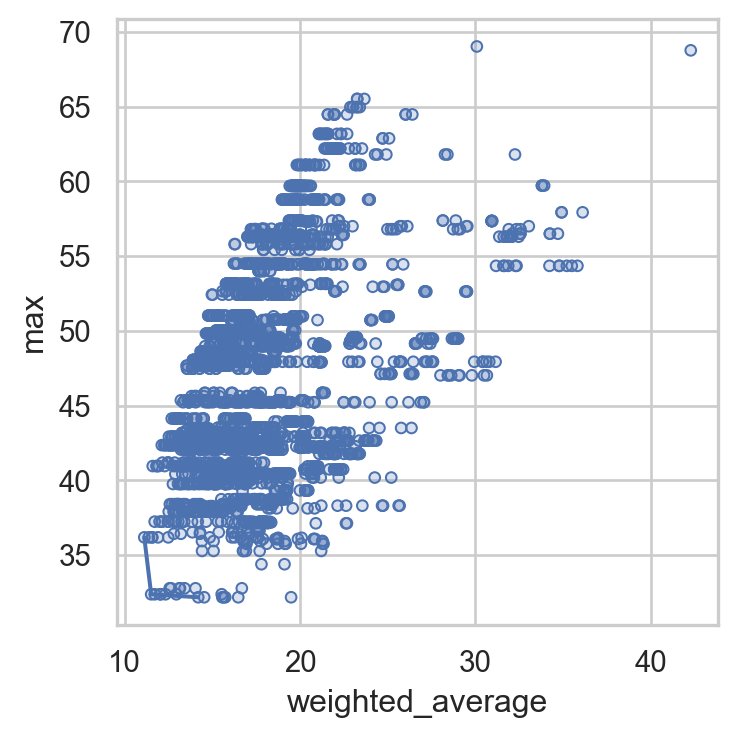

In [13]:
solution_3.plot_simple_pareto_front()

We can change what it's plotting. 

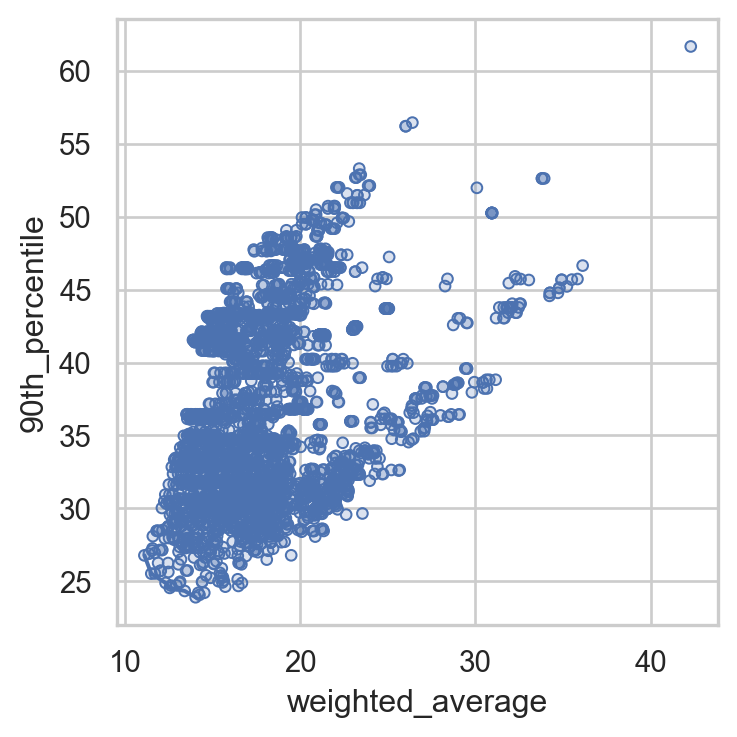

In [14]:
solution_3.plot_simple_pareto_front(y_axis="90th_percentile")

We can hide the individual points if the pareto front is hard to see. 

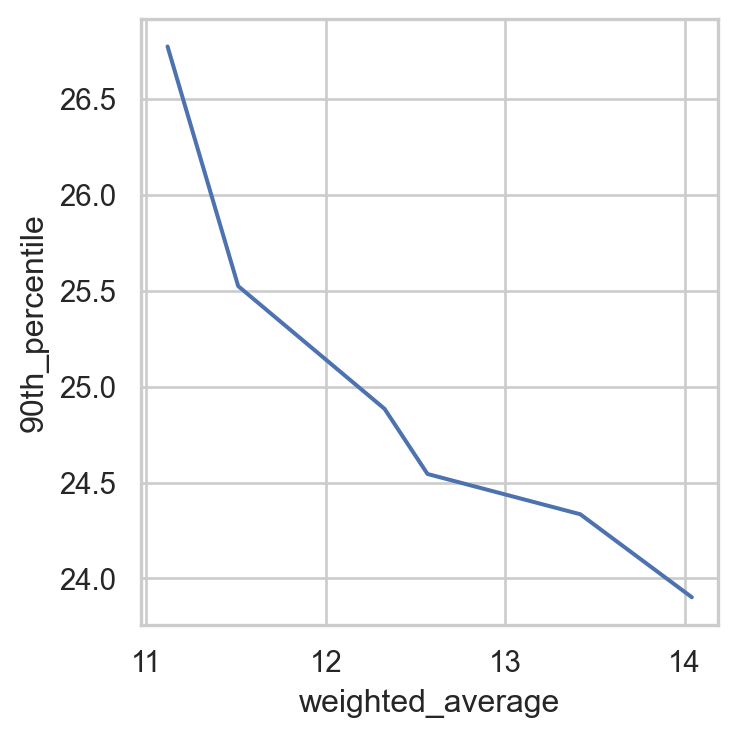

In [15]:
solution_3.plot_simple_pareto_front(y_axis="90th_percentile", show_points=False)

We can also ask it to create a plot of every pair of metrics. 

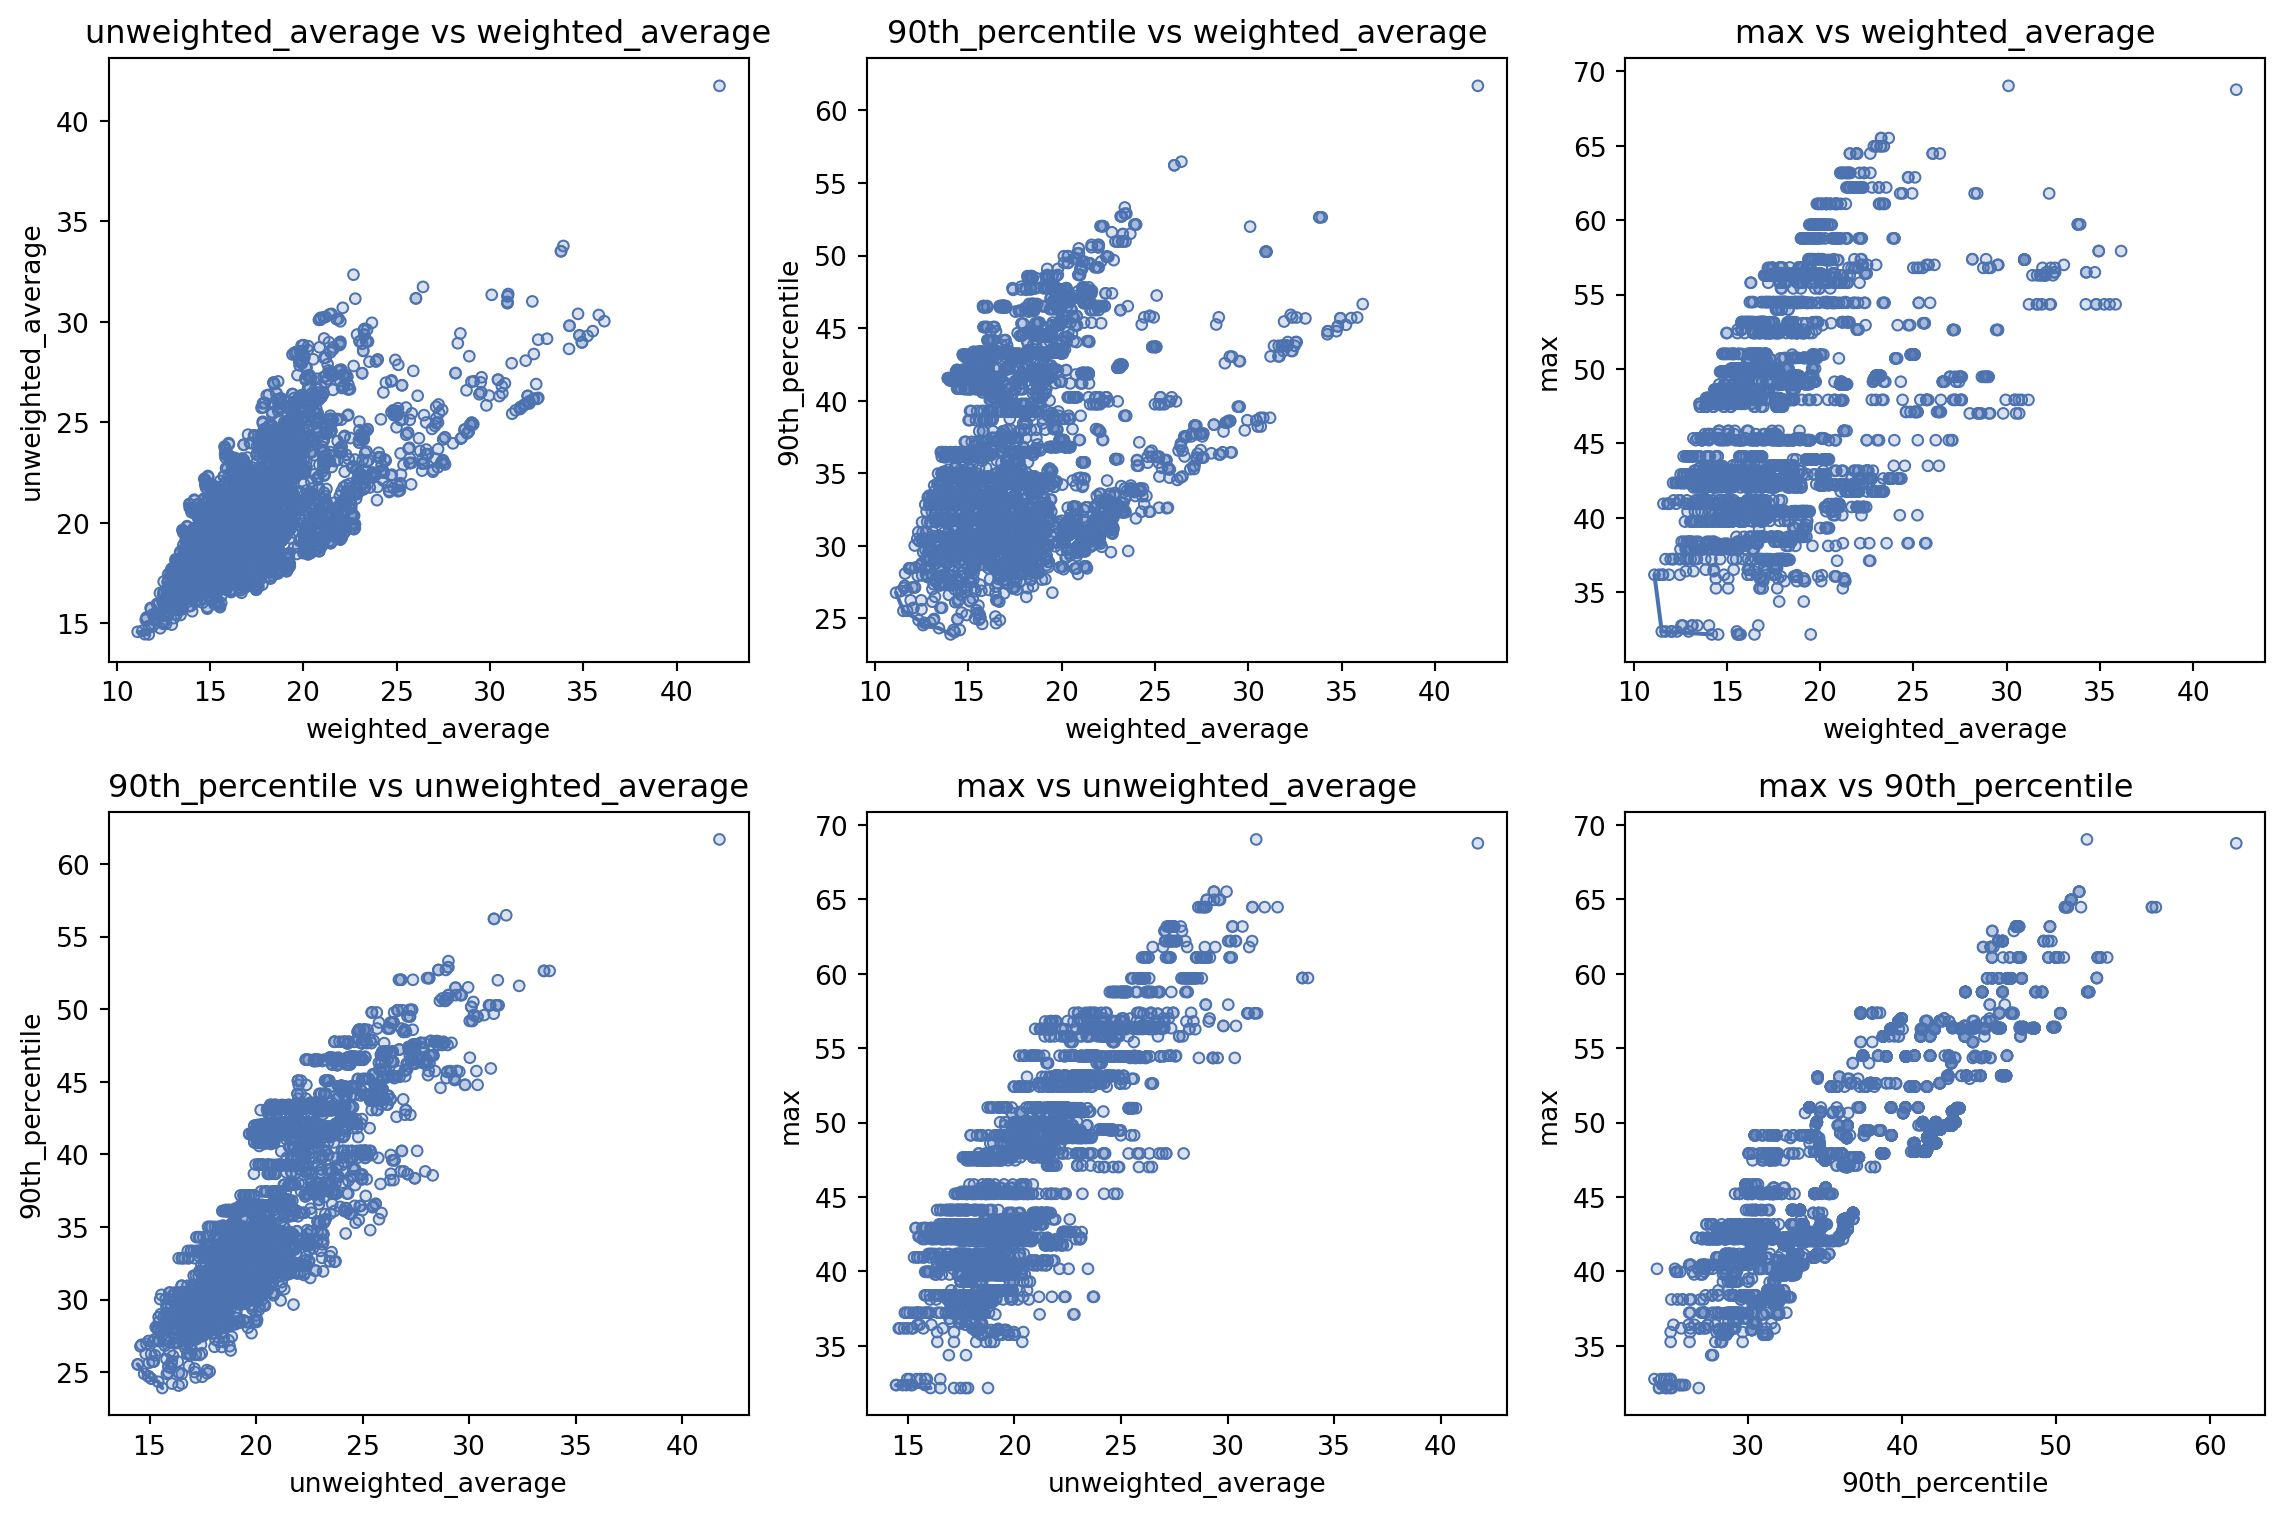

In [16]:
solution_3.plot_all_metric_pareto_front()

### Travel time distribution

Let's take a quick look at how much the travel time varied for our best solution. 

In [17]:
solution_3.plot_travel_time_distribution()

How did the top 5 compare? 

In [18]:
solution_3.plot_travel_time_distribution(top_n=5)

We can visualise the differences per region more easily by setting `compare_to_best=True`. 

In [19]:
solution_3.plot_travel_time_distribution(top_n=5, compare_to_best=True)